In [ ]:
#Setup e caricamento
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

uploaded = files.upload()
df = pd.read_csv('lecce_turismo_pulito.csv')

# Ricostruiamo i dati provinciali e le previsioni
df_provincia = df.groupby('anno').agg(
    arrivi_totali    = ('arr_tot_tot', 'sum'),
    presenze_totali  = ('pre_tot_tot', 'sum'),
    arrivi_italiani  = ('arr_tot_res', 'sum'),
    arrivi_stranieri = ('arr_tot_nonres', 'sum'),
).reset_index()

df_provincia['permanenza_media'] = (
    df_provincia['presenze_totali'] / df_provincia['arrivi_totali']
).round(2)

df_provincia['pct_stranieri'] = (
    df_provincia['arrivi_stranieri'] / df_provincia['arrivi_totali'] * 100
).round(1)

# Previsioni dal notebook 3
previsioni = pd.DataFrame({
    'anno': [2025, 2026, 2027, 2028],
    'arrivi_previsti':    [1497008, 1617104, 1737200, 1857625],
    'scenario_min':       [1444896, 1506594, 1517772, 1535204],
    'scenario_max':       [1544736, 1724104, 1930925, 2154353],
})

print("Dati pronti")
print(f"Ultimo anno disponibile: {df_provincia['anno'].max()}")
print(f"Arrivi 2024: {df_provincia[df_provincia['anno']==2024]['arrivi_totali'].values[0]:,.0f}")

Saving lecce_turismo_pulito.csv to lecce_turismo_pulito.csv
Dati pronti
Ultimo anno disponibile: 2024
Arrivi 2024: 1,351,834


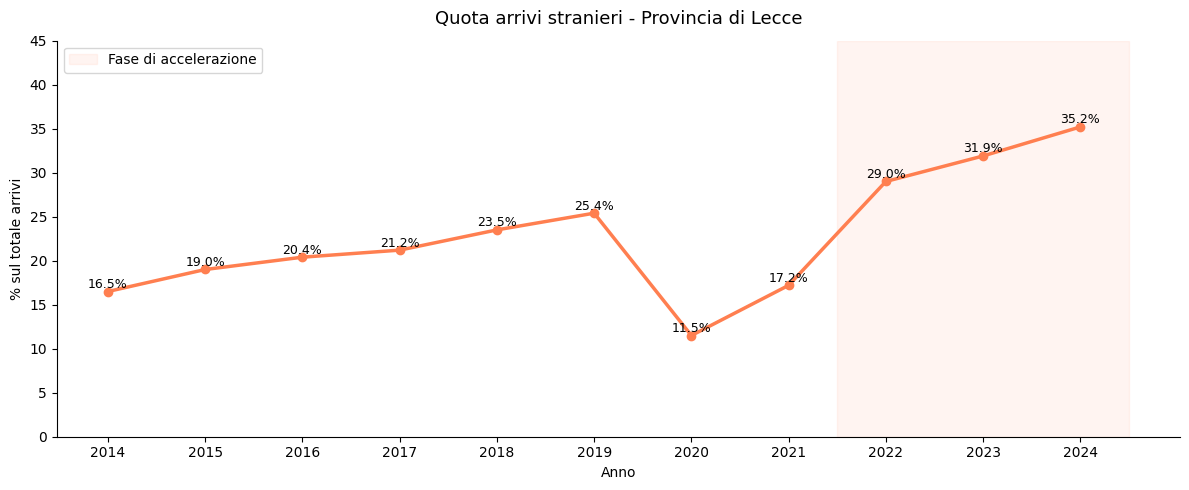

Crescita arrivi stranieri 2019→2024: +73.5%


In [ ]:
#Insight 1: La crescita degli stranieri la tendenza più importante
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_provincia['anno'], df_provincia['pct_stranieri'],
        marker='o', linewidth=2.5, color='coral')

# Evidenzia il salto post-2021
ax.axvspan(2021.5, 2024.5, alpha=0.08, color='coral', label='Fase di accelerazione')

for _, row in df_provincia.iterrows():
    ax.text(row['anno'], row['pct_stranieri'] + 0.4,
            f"{row['pct_stranieri']:.1f}%", ha='center', fontsize=9)

ax.set_title('Quota arrivi stranieri - Provincia di Lecce', fontsize=13, pad=12)
ax.set_xlabel('Anno')
ax.set_ylabel('% sul totale arrivi')
ax.set_ylim(0, 45)
ax.set_xticks(df_provincia['anno'])
ax.legend()

plt.tight_layout()
plt.savefig('insight_stranieri.png', dpi=150, bbox_inches='tight')
plt.show()

# Calcolo crescita stranieri
arr_str_2019 = df_provincia[df_provincia['anno']==2019]['arrivi_stranieri'].values[0]
arr_str_2024 = df_provincia[df_provincia['anno']==2024]['arrivi_stranieri'].values[0]
crescita = (arr_str_2024 / arr_str_2019 - 1) * 100
print(f"Crescita arrivi stranieri 2019→2024: +{crescita:.1f}%")

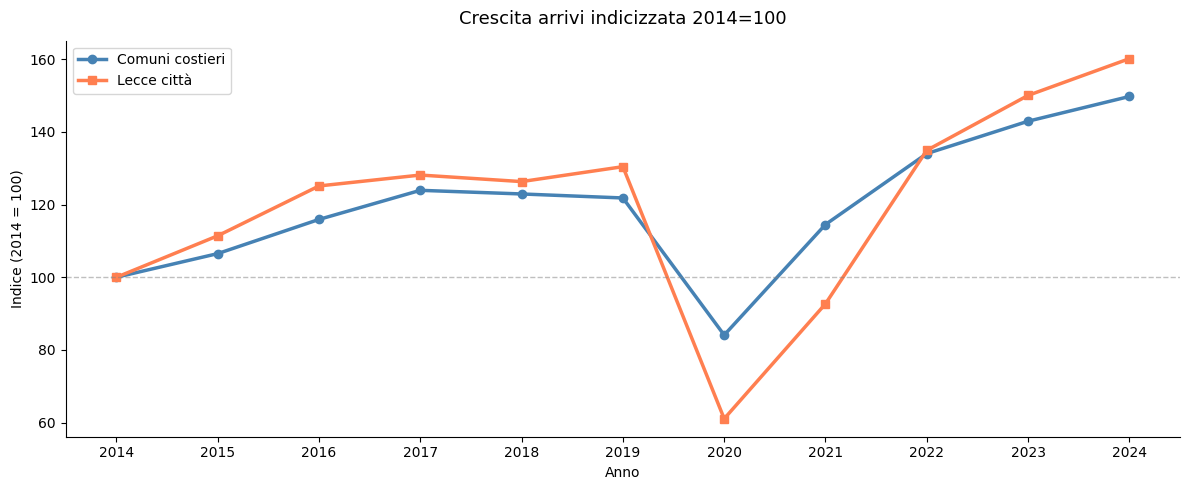

In [ ]:
#Insight 2: I comuni costieri crescono più della media
# Comuni costieri principali vs Lecce città
costieri = ['Gallipoli', 'Otranto', 'Ugento', 'Melendugno',
            'Porto Cesareo', 'Nardò', 'Santa Cesarea Terme']

df_costieri = df[df['comune'].isin(costieri)].groupby('anno')['arr_tot_tot'].sum().reset_index()
df_lecce_city = df[df['comune'] == 'Lecce'].groupby('anno')['arr_tot_tot'].sum().reset_index()

# Indicizziamo al 2014 = 100
base_costieri = df_costieri[df_costieri['anno']==2014]['arr_tot_tot'].values[0]
base_lecce    = df_lecce_city[df_lecce_city['anno']==2014]['arr_tot_tot'].values[0]

df_costieri['indice']   = (df_costieri['arr_tot_tot'] / base_costieri * 100).round(1)
df_lecce_city['indice'] = (df_lecce_city['arr_tot_tot'] / base_lecce * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_costieri['anno'], df_costieri['indice'],
        marker='o', linewidth=2.5, color='steelblue', label='Comuni costieri')
ax.plot(df_lecce_city['anno'], df_lecce_city['indice'],
        marker='s', linewidth=2.5, color='coral', label='Lecce città')
ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Crescita arrivi indicizzata 2014=100', fontsize=13, pad=12)
ax.set_xlabel('Anno')
ax.set_ylabel('Indice (2014 = 100)')
ax.set_xticks(df_provincia['anno'])
ax.legend()

plt.tight_layout()
plt.savefig('insight_costieri_vs_lecce.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Insight 3: Raccomandazioni operative
print("""
╔══════════════════════════════════════════════════════════════════╗
║         RACCOMANDAZIONI OPERATIVE - PROVINCIA DI LECCE          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INTERNAZIONALIZZAZIONE                                       ║
║     Gli stranieri sono passati dal 14% al 35% degli arrivi      ║
║     tra 2014 e 2024. Le strutture ricettive dovrebbero           ║
║     investire in comunicazione multilingua e presenza            ║
║     su piattaforme internazionali (Booking, Airbnb, ecc.)        ║
║                                                                  ║
║  2. DESTAGIONALIZZAZIONE                                         ║
║     La permanenza media scende sotto le 4.5 notti dal 2022.     ║
║     Opportunità di sviluppare offerte per spalle di stagione     ║
║     (aprile-maggio, settembre-ottobre) per aumentare             ║
║     la durata media del soggiorno.                               ║
║                                                                  ║
║  3. DISTRIBUZIONE TERRITORIALE                                   ║
║     Lecce cresce come destinazione urbana e culturale.           ║
║     I comuni costieri crescono più rapidamente.                  ║
║     Potenziale per itinerari integrati mare+cultura.             ║
║                                                                  ║
║  4. CAPACITÀ RICETTIVA                                           ║
║     Con 1.5M arrivi previsti nel 2025 (+10% vs 2024),           ║
║     le strutture devono pianificare la capacità                  ║
║     in anticipo, specialmente luglio-agosto.                     ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         RACCOMANDAZIONI OPERATIVE - PROVINCIA DI LECCE          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INTERNAZIONALIZZAZIONE                                       ║
║     Gli stranieri sono passati dal 14% al 35% degli arrivi      ║
║     tra 2014 e 2024. Le strutture ricettive dovrebbero           ║
║     investire in comunicazione multilingua e presenza            ║
║     su piattaforme internazionali (Booking, Airbnb, ecc.)        ║
║                                                                  ║
║  2. DESTAGIONALIZZAZIONE                                         ║
║     La permanenza media scende sotto le 4.5 notti dal 2022.     ║
║     Opportunità di sviluppare offerte per spalle di stagione     ║
║     (aprile-maggio, settembre-ottobre) per aumentare             ║
║     la durata media del soggiorno.

In [ ]:
# Comento finale
# ============================================================
# NOTEBOOK 4 - INSIGHT DI BUSINESS
# ============================================================
# Sintesi dei principali insight emersi dall'analisi:
#
# 1. Crescita strutturale confermata: +57% arrivi 2014→2024
# 2. Internazionalizzazione accelerata: stranieri x3 dal 2019
# 3. Lecce e costa crescono in modo complementare
# 4. Permanenza media in leggero calo: opportunità di offerta
# 5. Previsione 2025: ~1.5M arrivi, scenario positivo confermato
#
# Limiti del modello:
# - Serie storica annuale (11 punti): buona per trend,
#   limitata per stagionalità mensile
# - Il trend post-Covid è eccezionalmente forte:
#   le previsioni al 2028 vanno lette con cautela
# - Dati non includono extra-ricettivo informale (B&B non censiti)
# ============================================================

print("Notebook 4 completato.")
print("Prossimo: Notebook 5 - Pricing Dinamico con dati InsideAirbnb")

Notebook 4 completato.
Prossimo: Notebook 5 - Pricing Dinamico con dati InsideAirbnb
